hough transform v1 (circles) major idea: it uses only edges

In [2]:
import copy

import numpy as np
import cv2

# Read image
img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename

# Convert the image to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Find the edges in the image using canny detector
img = cv2.medianBlur(img, 5)
edges = cv2.Canny(img, 50, 200)
# img = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)

# Detect points that form a line
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 68, minLineLength=15, maxLineGap=250)
circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 100, param1=50, param2=30, minRadius=0, maxRadius=0)
circles = np.uint16(np.around(circles))
for i in circles[0, :]:
    # draw the outer circle
    cv2.circle(img, (i[0], i[1]), i[2], (0, 255, 0), 2)
    # draw the center of the circle
    cv2.circle(img, (i[0], i[1]), 2, (0, 0, 255), 3)
#lines = cv2.HoughLinesP(edges, 1, np.pi/180, minLineLength=10, maxLineGap=250)
# Draw lines on the image
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
# Show result
cv2.imshow('lanes', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

hough transform v2 (ellipses)

In [510]:
import cv2
import numpy as np
import random
from matplotlib import pyplot as plt
from skimage.feature import canny
import pandas as pd
import math
import time


# def canny(img,sigma = 0, low_threshold = 25, high_threshold = 30,mask=True):
#     return cv2.Canny(img,low_threshold,high_threshold,sigma=sigma,mask=mask)

class FindEllipseRHT(object):
    """ find a ellipse by randomized Hough Transform"""

    def __init__(self, phase_img, mask):
        # phase image
        self.origin = self.assert_img(phase_img)
        self.mask = mask

        # canny edge operator
        self.edge = None
        self.edge_pixels = None

        # settings
        self.max_iter = 800
        self.major_bound = [100, 250]
        self.minor_bound = [80, 250]
        self.flattening_bound = 0.8

        # plot
        self.black = None

        # accumulator
        self.accumulator = []
        self.score_threshold = 7

    def assert_img(self, img):
        try:
            assert len(img.shape) == 2
        except AttributeError:
            raise AttributeError("img is not a numpy array!")
        return img

    def assert_edge_pixels(self, edge_pixels):
        if len(edge_pixels) == 0:
            raise AssertionError("no edge!")

    def point_out_of_image(self, point):
        """ point X, Y"""
        if point[0] < 0 or point[0] >= self.edge.shape[1] or point[1] < 0 or point[1] >= self.edge.shape[0]:
            return True
        else:
            return False

    def ellipse_out_of_image(self, pad_img, pad_width):
        if np.sum(pad_img[:pad_width, :]) + np.sum(pad_img[-pad_width:, :]) + np.sum(pad_img[:, :pad_width]) + np.sum(
                pad_img[:, -pad_width:]) > 0:
            return True
        else:
            return False

    def canny_edge_detector(self, img):
        edged_image = canny(img, sigma=3.5, low_threshold=25, high_threshold=30, mask=self.mask)
        edge = np.zeros(edged_image.shape, dtype=np.uint8)
        edge[edged_image == True] = 255
        edge[edged_image == False] = 0
        plt.figure()
        plt.imshow(edge)
        plt.show()
        return edge

    def run(self, debug_mode=False, plot_mode=False):
        # seed
        random.seed((time.time() * 100) % 50)
        self.max_axis = 1000

        # canny
        self.edge = self.canny_edge_detector(self.origin)
        # print(self.edge)
        # find coordinates of edge
        edge_pixels = np.array(np.where(self.edge == 255)).T
        self.assert_edge_pixels(edge_pixels)
        self.edge_pixels = [p for p in edge_pixels]

        # demo
        self.black = np.zeros(self.edge.shape, dtype=np.uint8)  # demo

        # determine the number of iteration
        # if len(self.edge_pixels) > 100:
        #     self.max_iter = len(self.edge_pixels) * 5

        if debug_mode:
            candidate = 0

        for count, i in enumerate(range(self.max_iter)):
            # find nice ellipse
            p1, p2, p3 = self.randomly_pick_point()
            point_package = [p1, p2, p3]

            # find center
            try:
                center = self.find_center(point_package)
            except np.linalg.LinAlgError as err:
                print(err)
                continue

            # assert center is reasonable
            if self.point_out_of_image(center):
                continue

            # find axis
            try:
                semi_axisx, semi_axisy, angle = self.find_semi_axis(point_package, center)
            except np.linalg.LinAlgError as err:
                print(err)
                continue

            # assert is ellipse
            if (semi_axisx is None) or (semi_axisy is None) or (math.isnan(semi_axisx)) or (math.isnan(semi_axisy)):
                continue

            # assert diameter
            if not self.assert_diameter(semi_axisx, semi_axisy):
                continue

            # plot
            center_plot = (int(round(center[0])), int(round(center[1])))
            if semi_axisx > semi_axisy:
                axis_plot = (int(round(semi_axisx)), int(round(semi_axisy)))
            else:
                axis_plot = (int(round(semi_axisy)), int(round(semi_axisx)))

            # bound
            pad_width = 2
            pad_black = np.zeros((self.edge.shape[0] + pad_width, self.edge.shape[1] + pad_width), dtype=np.uint8)
            # print(axis_plot)

            if math.fabs(axis_plot[0]) > self.max_axis or math.fabs(axis_plot[1]) > self.max_axis:
                continue

            pad_black = cv2.ellipse(pad_black, (center_plot[0] + pad_width, center_plot[1] + pad_width), axis_plot,
                                    angle * 180 / np.pi, 0, 360, color=[255, 0, 0], thickness=1)
            if self.ellipse_out_of_image(pad_black, pad_width):
                continue

            if plot_mode:
                self.black = cv2.ellipse(self.black, center_plot, axis_plot, angle * 180 / np.pi, 0, 360,
                                         color=[255, 0, 0], thickness=1)

            # accumulate
            similar_idx = self.is_similar(center[0], center[1], semi_axisx, semi_axisy, angle)
            if similar_idx == -1:
                score = 1
                # print("append!!")
                self.accumulator.append([center[0], center[1], semi_axisx, semi_axisy, angle, score])
            else:
                # score += 1
                self.accumulator[similar_idx][-1] += 1
                # average weights
                w = self.accumulator[similar_idx][-1]
                if w >=4:
                    break
                self.accumulator[similar_idx][0] = self.average_weight(self.accumulator[similar_idx][0], center[0], w)
                self.accumulator[similar_idx][1] = self.average_weight(self.accumulator[similar_idx][1], center[1], w)
                self.accumulator[similar_idx][2] = self.average_weight(self.accumulator[similar_idx][2], semi_axisx, w)
                self.accumulator[similar_idx][3] = self.average_weight(self.accumulator[similar_idx][3], semi_axisy, w)
                self.accumulator[similar_idx][4] = self.average_weight(self.accumulator[similar_idx][4], angle, w)

            # plot candidate
            if debug_mode:
                candidate += 1
                if candidate == 10:
                    print("axis_plot", 2 * axis_plot[0], 2 * axis_plot[1])
                    self.black = cv2.ellipse(self.black, center_plot, axis_plot, angle * 180 / np.pi, 0, 360,
                                             color=[255, 0, 0], thickness=1)
                    self.black[int(center[1]), int(center[0])] = 230
                    self.find_center(point_package, plot_mode=True)
                    for point in point_package:
                        self.black[point[1], point[0]] = 80
                    break

        if plot_mode or debug_mode:
            plt.figure()  # demo
            plt.title("nice ellipse")
            plt.imshow(self.black, cmap='jet')
            plt.show()

        # sort ellipse candidates
        self.accumulator = np.array(self.accumulator)
        df = pd.DataFrame(data=self.accumulator, columns=['x', 'y', 'axis1', 'axis2', 'angle', 'score'])
        df = df.sort_values(by=['score'], ascending=False)
        
        # select the ellipses with the highest score
        best = np.squeeze(np.array(df.iloc[0]))
        p, q, a, b = list(map(int, np.around(best[:4])))
        if plot_mode:
            self.plot_best(p, q, a, b, best[-2])
        print("score: ", best[-1])
        self.inner_outer_phase(p, q, a, b, best[-2])
        return self.accumulator

    def plot_best(self, p, q, a, b, angle):
        # plot best ellipse
        result = np.zeros(self.edge.shape, dtype=np.uint8)
        if a > b:
            result = cv2.ellipse(result, (p, q), (a, b), angle * 180 / np.pi, 0, 360, color=[255, 0, 0], thickness=1)

        else:
            result = cv2.ellipse(result, (p, q), (b, a), angle * 180 / np.pi, 0, 360, color=[255, 0, 0], thickness=1)

        # # fig, ax = plt.subplots(1,2,2)
        # ax[0].imshow(self.origin, cmap='jet', vmax=255, vmin=0)
        # ax[0].set_title("phase image")
        crop = self.origin.copy()
        crop[self.edge == 255] = 0  # blue
        crop[result == 255] = 230  # red
        # ax[1].imshow(crop, cmap='jet', vmax=255, vmin=0)
        # ax[1].set_title("Hough ellipse detector")
        # fig.show()
        print(crop)
        plt.figure()
        plt.imshow(crop)
        plt.show()

    def inner_outer_phase(self, p, q, a, b, angle):
        ellipse_label = np.zeros(self.origin.shape, dtype=np.uint8)
        if a > b:
            ellipse_label = cv2.ellipse(ellipse_label, (p, q), (a, b), angle * 180 / np.pi, 0, 360, color=[255, 0, 0],
                                        thickness=-1)
        else:
            ellipse_label = cv2.ellipse(ellipse_label, (p, q), (b, a), angle * 180 / np.pi, 0, 360, color=[255, 0, 0],
                                        thickness=-1)
        inner_list = self.origin[ellipse_label == 255]
        outer_list = self.origin[ellipse_label != 255]
        inner_mean = np.mean(inner_list)
        inner_std = np.std(inner_list)
        outer_mean = np.mean(outer_list)
        outer_std = np.std(outer_list)
        print("inner outer std: ", inner_std, outer_std)
        print("phase ratio: ", round(inner_mean / outer_mean, 3))

    def randomly_pick_point(self):
        ran = random.sample(self.edge_pixels, 3)
        return (ran[0][1], ran[0][0]), (ran[1][1], ran[1][0]), (ran[2][1], ran[2][0])

    def find_center(self, pt, plot_mode=False):
        size = 7
        m, c = 0, 0
        m_arr = []
        c_arr = []

        # pt[0] is p1; pt[1] is p2; pt[2] is p3;
        for i in range(len(pt)):
            # find tangent line
            xstart = pt[i][0] - size // 2
            xend = pt[i][0] + size // 2 + 1
            ystart = pt[i][1] - size // 2
            yend = pt[i][1] + size // 2 + 1
            crop = self.edge[ystart: yend, xstart: xend].T
            proximal_point = np.array(np.where(crop == 255)).T
            proximal_point[:, 0] += xstart
            proximal_point[:, 1] += ystart

            # fit straight line
            A = np.vstack([proximal_point[:, 0], np.ones(len(proximal_point[:, 0]))]).T
            m, c = np.linalg.lstsq(A, proximal_point[:, 1], rcond=None)[0]
            m_arr.append(m)
            c_arr.append(c)
            if plot_mode:
                self.black = self.plot_line(self.black, m, c)

        # find intersection
        slope_arr = []
        intercept_arr = []
        for i, j in zip([0, 1], [1, 2]):
            # intersection
            coef_matrix = np.array([[m_arr[i], -1], [m_arr[j], -1]])
            dependent_variable = np.array([-c_arr[i], -c_arr[j]])
            t12 = np.linalg.solve(coef_matrix, dependent_variable)
            # middle point
            m1 = ((pt[i][0] + pt[j][0]) / 2, (pt[i][1] + pt[j][1]) / 2)
            # bisector
            slope = (m1[1] - t12[1]) / (m1[0] - t12[0])
            intercept = (m1[0] * t12[1] - t12[0] * m1[1]) / (m1[0] - t12[0])
            # self.plot_line(slope, intercept)
            slope_arr.append(slope)
            intercept_arr.append(intercept)
            if plot_mode:
                self.black = self.plot_line(self.black, slope, intercept)

        # find center
        coef_matrix = np.array([[slope_arr[0], -1], [slope_arr[1], -1]])
        dependent_variable = np.array([-intercept_arr[0], -intercept_arr[1]])
        center = np.linalg.solve(coef_matrix, dependent_variable)
        return center

    def find_semi_axis(self, pt, center):
        # shift to origin
        npt = []
        for p in pt:
            npt.append((p[0] - center[0], p[1] - center[1]))
        # semi axis
        x1 = npt[0][0]
        y1 = npt[0][1]
        x2 = npt[1][0]
        y2 = npt[1][1]
        x3 = npt[2][0]
        y3 = npt[2][1]
        coef_matrix = np.array(
            [[x1 ** 2, 2 * x1 * y1, y1 ** 2], [x2 ** 2, 2 * x2 * y2, y2 ** 2], [x3 ** 2, 2 * x3 * y3, y3 ** 2]])
        dependent_variable = np.array([1, 1, 1])
        A, B, C = np.linalg.solve(coef_matrix, dependent_variable)

        # major = np.sqrt(np.cos(2*angle) / (a - (a + c) * np.pow(np.sin(angle), 2)));
        # new_minor_axis = major / np.sqrt((a + c) * np.pow(major,2) - 1)

        if self.assert_valid_ellipse(A, B, C):
            angle = self.calculate_rotation_angle_v2(A, B, C)
            # assert np.isnan(angle)
            # angle = self.calculate_angle(A, B, C)
            AXIS_MAT = np.array([[np.sin(angle) ** 2, np.cos(angle) ** 2], [np.cos(angle) ** 2, np.sin(angle) ** 2]])
            AXIS_MAT_ANS = np.array([A, C])
            X, Y = np.linalg.solve(AXIS_MAT, AXIS_MAT_ANS)
            major = 1 / np.sqrt(max(X, Y))
            # major = np.sqrt(np.cos(2*angle)/(A-(A+C)*np.sin(angle)**2))
            minor = 1 / np.sqrt(min(X, Y))
            # minor = major/np.sqrt((A+C)*major**2-1)
            # A, B, C = np.sqrt(np.abs(np.reciprocal([A, B, C])))
            # print(angle)

            return major, minor, angle
        else:
            return None, None, None

    def is_similar(self, p, q, axis1, axis2, angle):  # todo can be faster using sets
        similar_idx = -1
        if self.accumulator is not None:
            for idx, e in enumerate(self.accumulator):
                # area dist
                area_dist = np.abs((np.pi * e[2] * e[3] - np.pi * axis1 * axis2))
                # center dist
                center_dist = np.sqrt((e[0] - p) ** 2 + (e[1] - q) ** 2)
                # angle dist
                # angle_dist = (e[4] - angle)**2
                angle_dist = (abs(e[4] - angle))
                # print(area_dist, center_dist, angle_dist)
                laxis_dist = abs(max(axis1, axis2) - max(e[2], e[3]))
                saxis_dist = abs(min(axis1, axis2) - min(e[2], e[3]))
                if (laxis_dist < 5) and (center_dist < 5) and (angle_dist < 0.1745) and (saxis_dist < 10):
                    return idx
        return similar_idx

    def calculate_rotation_angle(self, a, b, c):
        if b == 0 and a < c:
            # 0 degree
            angle = 0
        elif b == 0 and c < a:
            # 90 degree
            angle = np.pi / 2
        elif b != 0:
            # tilt
            angle = np.arctan((c - a - np.sqrt((a - c) ** 2 + b ** 2)) / b)
        else:
            # circle, no angle
            angle = 0

        if angle < 0:
            angle += np.pi
        elif angle > np.pi:
            angle -= np.pi
        return angle

    def calculate_rotation_angle_v2(self, a, b, c):
        if a == c:
            angle = 0
        else:
            angle = 0.5 * np.arctan((2 * b) / (a - c))

        if a > c:
            if b < 0:
                angle = angle - (-0.5 * np.pi)
            elif b > 0:
                angle = angle - (0.5 * np.pi)
        # if not np.isnan(angle):
        #     pass
        # else:
        # print(angle,a, b, c)
        return angle

    def assert_valid_ellipse(self, a, b, c):
        if a * c - b ** 2 > 0:
            return True
        else:
            return False

    def assert_diameter(self, semi_axis_x, semi_axis_y):
        if semi_axis_x > semi_axis_y:
            major, minor = semi_axis_x, semi_axis_y
        else:
            major, minor = semi_axis_y, semi_axis_x
        # diameter
        if (self.major_bound[0] < 2 * major < self.major_bound[1]) and (
                self.minor_bound[0] < 2 * minor < self.minor_bound[1]):
            # Flattening
            flattening = (major - minor) / major
            if flattening < self.flattening_bound:
                return True
        return True

    def average_weight(self, old, now, score):
        return (old * score + now) / (score + 1)

    def plot_line(self, img, m, c):
        if m == 0:
            return
        solution = []
        # left bound
        x = 0
        if 0 <= m * x + c < self.edge.shape[0]:
            solution.append((x, int(round(m * x + c))))

        # right bound
        x = self.edge.shape[1] - 1
        if 0 <= m * x + c < self.edge.shape[0]:
            solution.append((x, int(round(m * x + c))))

        # upper bound
        y = 0
        if 0 <= (y - c) / m < self.edge.shape[1]:
            solution.append((int(round((y - c) / m)), y))

        # lower bound
        y = self.edge.shape[0] - 1
        if 0 <= (y - c) / m < self.edge.shape[1]:
            solution.append((int(round((y - c) / m)), y))

        img = cv2.line(img, solution[0], solution[1], color=50, thickness=1)
        return img


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


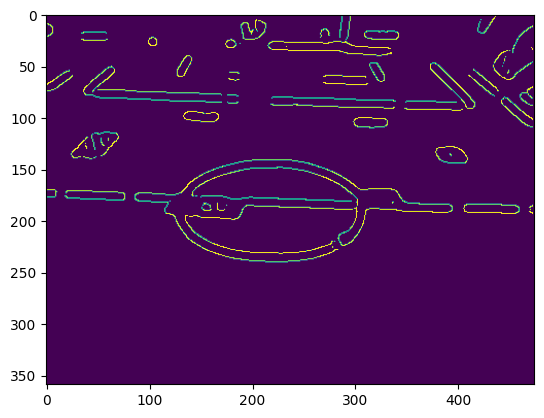

C:\Users\shishkin_i\AppData\Local\Temp\ipykernel_23124\3351799319.py:328: RuntimeWarning: invalid value encountered in sqrt
  minor = 1 / np.sqrt(min(X, Y))


Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix
Singular matrix


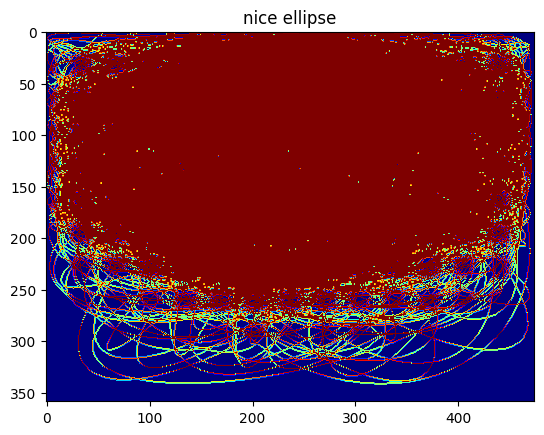

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


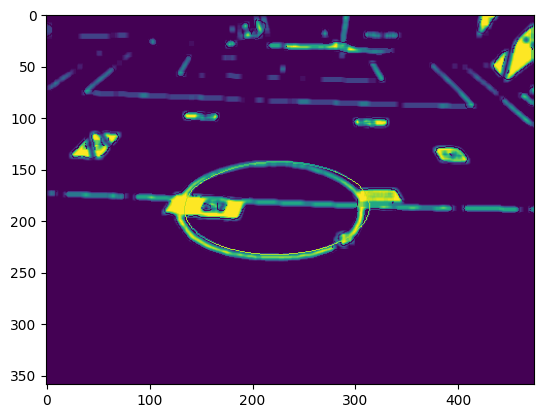

score:  4.0
inner outer std:  73.98481787658238 38.095182850954885
phase ratio:  3.958
time consume:  6.487905502319336
[[223.55636706843384, 188.03032037381527, 45.37550353047099, 90.4579137549858, -0.010903084118969961, 4.0], [226.66680726503483, 191.29840346601054, 46.17048351538676, 80.55234068689059, 0.008832704894126159, 3.0], [219.83791033862093, 185.83469749606513, 44.62121066180271, 90.69773689959678, 0.01697829519948957, 3.0], [194.69126196309267, 131.5882722518153, 28.194625613113214, 172.41993492903725, 0.32397634843943096, 2.0], [221.2597076112204, 202.40983789644648, 30.664336285105332, 83.63171115426563, 0.04711531208967646, 2.0], [228.9194514071704, 103.0641184464207, 80.81884945109795, 197.36705268891023, 0.020702152385910944, 2.0], [301.09925289150414, 108.42977672330643, 82.12362030756397, 127.95532720638602, 0.14874751915110593, 2.0], [292.6813688486757, 60.716052537515765, 25.975119119883157, 177.61470621692322, 0.15477639947117341, 2.0], [206.81373710230037, 206.0

In [518]:
# from randomizedHoughEllipseDetection import FindEllipseRHT
import time
import cv2
import matplotlib.pyplot as plt
import numpy as np

path = "D:\\1LAB"
original_image = cv2.imread("../tmp/hehe2.png")#"../tmp/v5_bacground.png"
from image_tuner import rgb_tune_from_params

original_image = rgb_tune_from_params(original_image, 128, 167, 196, 255, 255, 255)
original_image = cv2.blur(original_image, (5, 5))
print(original_image)
# original_image = cv2.cvtColor(original_image,cv2.COLOR_RGB2GRAY)
# mask = cv2.imread(path + "\\1619_mask.png", 0)
mask_binary = np.zeros(original_image.shape, dtype=bool)
mask_binary[original_image == 255] = False
mask_binary[original_image != 255] = True

time1 = time.time()
test = FindEllipseRHT(original_image, mask_binary)
# plt.figure()
# plt.imshow(original_image)
# plt.show()
test.max_iter = 20000
data = test.run(plot_mode=True, debug_mode=False)
data = data.tolist()
data = sorted(data, key=lambda item: -item[5])
time2 = time.time()
print("time consume: ", time2 - time1)
print(data)
# angle = 0.5
# A = 2
# C= 3
# AXIS_MAT = np.array([[np.sin(angle)**2 , np.cos(angle)**2], [np.cos(angle)**2, np.sin(angle)**2]])
# AXIS_MAT_ANS = np.array([A, C])
# np.linalg.solve(AXIS_MAT,AXIS_MAT_ANS)

In [11]:
from image_tuner import tune_test
# tune_test("../tmp/v5_bacground.png")#27,32,32,167,207,162
from image_tuner import rgb_tune_test
# rgb_tune_test("../tmp/v5_bacground.png")
from image_tuner import rgb_tune_from_params

original_image = rgb_tune_from_params(original_image, 128, 167, 196, 255, 255, 255)
print("hf")
plt.imshow(original_image)

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\arithm.cpp:1876: error: (-209:Sizes of input arguments do not match) The lower boundary is neither an array of the same size and same type as src, nor a scalar in function 'cv::inRange'


gradient decent with best ellipse possible

In [71]:
import math
import torch
import cv2

import matplotlib.pyplot as plt

# img = cv2.imread('../tmp/v5_bacground.png', cv2.IMREAD_COLOR)  # road.png is the filename
# generated = torch.randn(5)*100
# print(generated)
# img = img*0+100
# img = cv2.ellipse(img,(int(generated[0]+100),int(generated[1]+100)),(abs(int(generated[2])),abs(int(generated[3]))),float(generated[4]),0,360,color=(0,0,0),thickness=10)
# ksize = (60,60)
# for i in range(10):
#     img = cv2.blur(img,ksize=ksize)
# Convert the image to grayscale
# img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# image_torch = torch.from_numpy(img)
# print(image_torch)
# plt.imshow(img)
# cv2.imshow("eheh",img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
# center = torch.tensor([0.,0.], requires_grad=True)
# ax = torch.tensor(0., requires_grad=True)
# bx = torch.tensor(0., requires_grad=True)
# width = torch.tensor(0., requires_grad=True)
# params = torch.randn((5), requires_grad=True)


error: OpenCV(4.10.0) d:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.simd_helpers.hpp:92: error: (-2:Unspecified error) in function '__cdecl cv::impl::`anonymous-namespace'::CvtHelper<struct cv::impl::`anonymous namespace'::Set<3,4,-1>,struct cv::impl::A0x85adec04::Set<1,-1,-1>,struct cv::impl::A0x85adec04::Set<0,2,5>,4>::CvtHelper(const class cv::_InputArray &,const class cv::_OutputArray &,int)'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 1


In [ ]:

# loss_BGD = []

In [317]:
# x_0 = torch.randn((1), requires_grad=True)
# y_0 = torch.randn((1), requires_grad=True)
# angle = torch.randn((1), requires_grad=True)
# a = torch.randn((1), requires_grad=True)
# b = torch.randn((1), requires_grad=True)

In [318]:
def points_on_ellipse(x_0, y_0, a, b, angle, n: int) -> list[(torch.tensor, torch.tensor)]:
    points = list()
    for i in range(n):
        point = (math.cos(i / math.pi / 2), math.sin(i / math.pi / 2))
        point = (point[0] * a, point[1] * b)
        point = (point[0] * torch.cos(angle) + point[1] * torch.sin(angle),
                 -point[0] * torch.sin(angle) + point[1] * torch.cos(angle))
        point = (point[0] + x_0, point[1] + y_0)
        points.append(point)
    return points

def points_on_line(from_x,from_y,to_x,to_y):
    ans = list()
    if math.fabs(from_x-to_x)>math.fabs(from_y-to_y):
        step_x = (to_x-from_x)/(to_y-from_y)
        for i in range(from_y,to_y,(to_y-from_y)/math.fabs(to_y-from_y)):
            ans.append((int(step_x*i+from_x),int(i+from_y)))
    else:
        step_y = (to_y-from_y)/(to_x-from_x)
        for i in range(from_x,to_x,(to_x-from_x)/math.fabs(to_x-from_x)):
            ans.append((int(i+from_x),int(step_y*i+from_y)))
    return ans

def metric_by_points(x_0, y_0, a, b, angle, n: int, data) -> torch.tensor:
    points = points_on_ellipse(x_0,y_0,a,b,angle,n)
    ans = torch.zeros(1)
    for i in range(n):
        for j in points_on_line(points[i][0],points[i][1],points[(i+1)%n][0],points[(i+1)][1]):
            if 0<=j[0]<=data.shape[0] and 0<=j[1]<=data.shape[1]:
                ans+=data[j[0]][j[1]]
    return ans

In [492]:
import copy


class TinyModel(torch.nn.Module):
    def __init__(self, x_0, y_0, a, b, angle):
        super(TinyModel, self).__init__()

        self.x_0 = torch.nn.Parameter(torch.tensor(x_0, requires_grad=True))
        self.y_0 = torch.nn.Parameter(torch.tensor(y_0, requires_grad=True))
        self.angle = torch.nn.Parameter(torch.tensor(angle, requires_grad=True))
        self.a = torch.nn.Parameter(torch.tensor(a, requires_grad=True))
        self.b = torch.nn.Parameter(torch.tensor(b, requires_grad=True))
        self.loss_BGD = []

    def convert(self, px_0, py_0, pangle, pa, pb):  #ax**2+bx+cy**2+dy+exy+f = 0
        # if abs(pa)<eps:
        #     pa += eps * torch.sign(pa)
        # if abs(pb)<eps:
        #     pb += eps * torch.sign(pb)
        s_ang = torch.sin(pangle)
        c_ang = torch.cos(pangle)
        return torch.stack(
            [c_ang ** 2 / pa ** 2 + s_ang ** 2 / pb ** 2, 2 * (c_ang * px_0 / pa ** 2 + s_ang * py_0 / pb ** 2),
             s_ang ** 2 / pa ** 2 + c_ang ** 2 / pb ** 2, 2 * (-s_ang * px_0 / pa ** 2 + c_ang * py_0 / pb ** 2),
             2 * (c_ang * s_ang) * (-1 / pa ** 2 + 1 / pb ** 2), (px_0 / pa) ** 2 + (py_0 / pb) ** 2 - 1])

    # params = 0
    def forward(self, x):
        # global params
        params = self.convert(self.x_0, self.y_0, self.angle, self.a, self.b)
        return torch.einsum('ij,j->i', x, params)


class Model:

    def __init__(self, x_0, y_0, a, b, angle):
        self.model = TinyModel(x_0, y_0, a, b, angle)
        self.eps = 1e-5
        self.loss_BGD = []

    # 
    def loss_c(self, val, X_v):
        perimeter = math.pi * torch.sqrt((self.model.a ** 2 + self.model.b ** 2) * 2)
        val =(val + 1 / (
                self.eps + val))-2+self.eps+0.1
        return torch.sqrt(torch.sum(
            val * torch.max(torch.zeros_like(X_v), X_v) + 1 / val * torch.min(torch.zeros_like(X_v),
                                                                              X_v)))  #/ perimeter # +self.model.a**2+self.model.b**2+self.model.angle**2

    # def loss_c(val):
    #     return torch.sum(val**2)**(0.2)#+torch.sum(params**3)

    # xs = torch.randn((5, 5))
    # print(loss_c(forward(xs)))
    def solve(self, img, debug=False, n_steps=1000):
        self.optim = torch.optim.Adam(self.model.parameters(), lr=10.1)
        X_v = torch.from_numpy(cv2.cvtColor(img, cv2.COLOR_BayerGR2GRAY))
        # print(X_v)
        X_1 = torch.stack([torch.ones((X_v.shape[0])) * size for size in range(0, X_v.shape[1])])
        #X_1 -= X_v.shape[1]//2
        X_2 = torch.stack([torch.ones((X_v.shape[1])) * size for size in range(0, X_v.shape[0])])
        #X_2 -= X_v.shape[0]//2
        X_2 = torch.transpose(X_2, 0, 1)
        if debug:
            print(X_1, X_2)
        # print(X_1.shape, X_2.shape)
        X_1 = torch.flatten(X_1)
        X_2 = torch.flatten(X_2)
        X_v = torch.flatten(X_v)
        X_v = torch.max(X_v) / 2 - X_v
        X = torch.stack([X_1 ** 2, X_1, X_2 ** 2, X_2, X_1 * X_2, torch.ones_like(X_1)])
        if debug:
            print(X)
        X = torch.transpose(X, 0, 1)
        loss = self.loss_c(self.model.forward(X), X_v)
        self.best_loss = 1e20
        self.best_model = copy.deepcopy(self.model)
        for i in range(n_steps):
            # making predictions with forward pass
            Y = self.model.forward(X)
            # calculating the loss between original and predicted data points
            loss = self.loss_c(Y, X_v)
            if debug:
                print(torch.min(Y))
                if torch.min(Y) < 0:
                    print(
                        "bbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbb")
            # storing the calculated loss in a list
            self.loss_BGD.append(loss.item())
            # backward pass for computing the gradients of the loss w.r.t to learnable parameters
            loss.backward()
            self.optim.step()
            self.optim.zero_grad()
            if i % 10 == 0 and debug:
                print(loss, " is loss")
                print(float(self.model.x_0), float(self.model.y_0), float(self.model.angle), float(self.model.a),
                      float(self.model.b), " is params")
            if loss < self.best_loss:
                self.best_loss = float(loss)
                self.best_model = copy.deepcopy(self.model)
        self.model = self.best_model
        return self.best_loss



In [495]:
best_metric = 1e9
best_enum = 0
val = 1
val = float((torch.randn((1))))*0.3+0.5
print(val)
for enum in range(int(len(data) * 0.9 * val), int(len(data) * 0.9 * val) + 10):
    if enum >= len(data):
        break
    i = data[enum]
    md = Model(i[0], i[1], i[2], i[3], i[4])
    metric = float(md.solve(original_image, n_steps=10))
    print(metric)
    if metric < best_metric:
        best_metric = metric
        best_enum = enum
# best_enum = 0
print(best_enum)
best_md = Model(data[best_enum][0], data[best_enum][1], data[best_enum][2], data[best_enum][3], data[best_enum][4])
best_md.solve(original_image, n_steps=1000, debug=True)

0.6661016762256622
12108.3564453125
11010.3349609375
15433.7197265625
7164.10205078125
2015.907470703125
23157.12109375
6293.12158203125
23656.40625
5799.10791015625
22926.30078125
965
tensor([[  0.,   0.,   0.,  ...,   0.,   0.,   0.],
        [  1.,   1.,   1.,  ...,   1.,   1.,   1.],
        [  2.,   2.,   2.,  ...,   2.,   2.,   2.],
        ...,
        [476., 476., 476.,  ..., 476., 476., 476.],
        [477., 477., 477.,  ..., 477., 477., 477.],
        [478., 478., 478.,  ..., 478., 478., 478.]]) tensor([[  0.,   1.,   2.,  ..., 356., 357., 358.],
        [  0.,   1.,   2.,  ..., 356., 357., 358.],
        [  0.,   1.,   2.,  ..., 356., 357., 358.],
        ...,
        [  0.,   1.,   2.,  ..., 356., 357., 358.],
        [  0.,   1.,   2.,  ..., 356., 357., 358.],
        [  0.,   1.,   2.,  ..., 356., 357., 358.]])
tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 2.2848e+05, 2.2848e+05,
         2.2848e+05],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 4.7800e+02, 4.7

2015.907470703125

Parameter containing:
tensor(191.3203, requires_grad=True) Parameter containing:
tensor(178.5937, requires_grad=True) Parameter containing:
tensor(-40.3008, requires_grad=True) Parameter containing:
tensor(86.1725, requires_grad=True) Parameter containing:
tensor(138.5992, requires_grad=True)


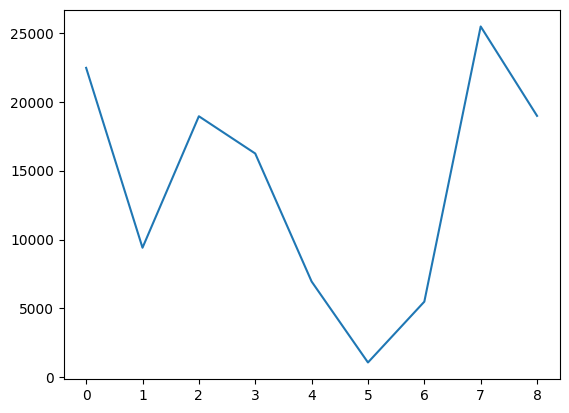

<class 'numpy.ndarray'>


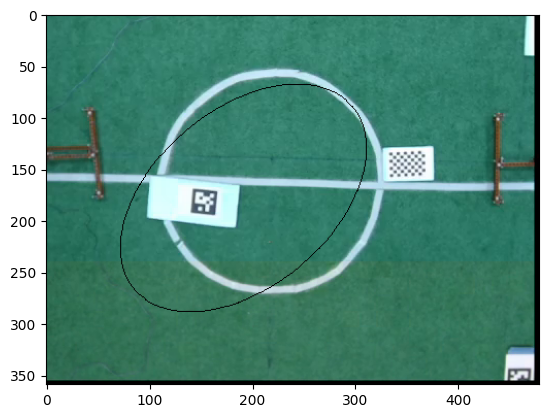

In [494]:

from functools import partial

# ax = plt.plot(loss_BGD, label="Batch Gradient Descent")
img = cv2.imread("../tmp/v5_bacground.png")
# img = original_image
fig, ax = plt.subplots()
ax.plot(best_md.loss_BGD)
print(best_md.model.x_0, best_md.model.y_0, best_md.model.angle, best_md.model.a, best_md.model.b)
# plt.xlabel('Epoch')
# plt.ylabel('Cost/Total loss')
# plt.legend()

# ax.set_yscale('function', functions=(partial(np.power, 10.0), np.log10))
# ax.set(xlim=(1,2000),ylim=(10,100))

# ax.set_yticks([1, 3, 3.5, 3.75, 4.0])
plt.show()

image = cv2.ellipse(img, (int(best_md.model.x_0), int(best_md.model.y_0)),
                    (abs(int(best_md.model.b)), abs(int(best_md.model.a))), float(best_md.model.angle), 0, 360,
                    color=(0, 0, 0))
# image = cv2.ellipse(img,(int(data[best_enum][0]),int(data[best_enum][1])),(abs(int(data[best_enum][2])),abs(int(data[best_enum][3]))),float(data[best_enum][4]),0,360,color=(0,0,0))
# print(image.shape)
print(type(image))
# image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(image)